In [2]:
import ultralytics

In [3]:
model = ultralytics.YOLO('best.pt')


In [4]:
import cv2
import pytesseract

In [5]:
# result = model(['Cars34.png'])
# for i in result:
#   i.save(filename = 'result.jpg')
#   img =cv2.imread('result.jpg')
#   cv2.imshow('Frame',img)
#   cv2.waitKey(10000)
#   cv2.destroyAllWindows()

In [ ]:
# video = cv2.VideoCapture('Traffic Flow In The Highway - 4K Stock Videos  NoCopyright  AllVideoFree-1920x1080-avc1-mp4a.mp4')

# while True:
#     suc, img = video.read()
#     if not suc:
#         break

#     # 👉 Resize frame (width, height)
#     img = cv2.resize(img, (800, 700))

#     result = model(img)
#     for i in result:
#         i.save(filename='result.jpg')
#         img = cv2.imread('result.jpg')

#     cv2.imshow('Frame', img)

#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break

# video.release()
# cv2.destroyAllWindows()


0: 576x640 2 license_plates, 207.7ms
Speed: 5.5ms preprocess, 207.7ms inference, 8.4ms postprocess per image at shape (1, 3, 576, 640)

0: 576x640 2 license_plates, 384.8ms
Speed: 5.5ms preprocess, 384.8ms inference, 2.5ms postprocess per image at shape (1, 3, 576, 640)

0: 576x640 1 license_plate, 385.8ms
Speed: 11.3ms preprocess, 385.8ms inference, 2.8ms postprocess per image at shape (1, 3, 576, 640)

0: 576x640 2 license_plates, 510.2ms
Speed: 10.2ms preprocess, 510.2ms inference, 3.5ms postprocess per image at shape (1, 3, 576, 640)

0: 576x640 2 license_plates, 403.5ms
Speed: 6.7ms preprocess, 403.5ms inference, 2.8ms postprocess per image at shape (1, 3, 576, 640)

0: 576x640 2 license_plates, 375.8ms
Speed: 10.2ms preprocess, 375.8ms inference, 2.9ms postprocess per image at shape (1, 3, 576, 640)

0: 576x640 1 license_plate, 385.1ms
Speed: 10.7ms preprocess, 385.1ms inference, 2.1ms postprocess per image at shape (1, 3, 576, 640)

0: 576x640 1 license_plate, 379.7ms
Speed: 10

In [17]:
import pandas as pd

data = {

"owner_name":["JEO"," AKSHAY"],
"house_name":["NK LON","VILLA View"],
"place":["Kochi","TVM"],
"phone":["1111111210","2222222222"],
"number_plate":["KL07AB1234","DL7CN5617"],
}

df = pd.DataFrame(data)

df

,owner_name,house_name,place,phone,number_plate
0,JEO,NK LON,Kochi,1111111210,KL07AB1234
1,AKSHAY,VILLA View,TVM,2222222222,DL7CN5617


In [8]:
# result = model(['Cars34.png'])
img = cv2.imread('Cars34.png')


In [9]:
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'


0: 544x640 1 license_plate, 114.2ms
Speed: 17.7ms preprocess, 114.2ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 640)


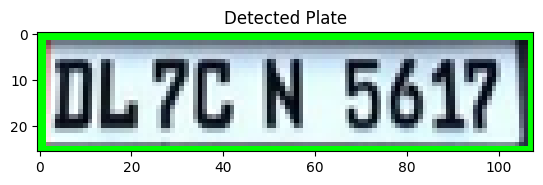

In [18]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("Cars34.png")

results = model(img)

for r in results:
    boxes = r.boxes.xyxy.cpu().numpy()

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)


        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)


        plate = img[y1:y2, x1:x2]


        plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
        plt.title("Detected Plate")
        plt.show()

In [20]:

text = pytesseract.image_to_string(plate)

print("Output:", text)

Output: DL7C N 5617



In [21]:
plate_number = text.strip().replace(" ", "")
print("Detected Plate:", plate_number)

Detected Plate: DL7CN5617


In [22]:
result = df[df["number_plate"] == plate_number]

In [23]:
if not result.empty:
    print("Owner Name :", result.iloc[0]["owner_name"])
    print("House Name :", result.iloc[0]["house_name"])
    print("Place :", result.iloc[0]["place"])
    print("Phone :", result.iloc[0]["phone"])
else:
    print("Vehicle not found in database")

Owner Name :  AKSHAY
House Name : VILLA View
Place : TVM
Phone : 2222222222
